In [2]:
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(perch_length, perch_weight, random_state=42)

# 훈련 세트와 테스트 세트를 2차원 배열로 바꿈
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

x_train.shape, x_test.shape

((42, 1), (14, 1))

In [4]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(include_bias=False)
poly.fit(x_train)
x_train_poly = poly.transform(x_train)
x_test_poly = poly.transform(x_test)
x_train_poly.shape, x_test_poly.shape

((42, 2), (14, 2))

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
lr.score(x_train_poly, y_train), lr.score(x_test_poly, y_test)

(0.9706807451768623, 0.9775935108325122)

In [7]:
lr.coef_, lr.intercept_

(array([-21.55792498,   1.01433211]), np.float64(116.05021078278315))

In [8]:
lr.coef_[0], lr.coef_[1]

(np.float64(-21.557924978837384), np.float64(1.0143321093767306))

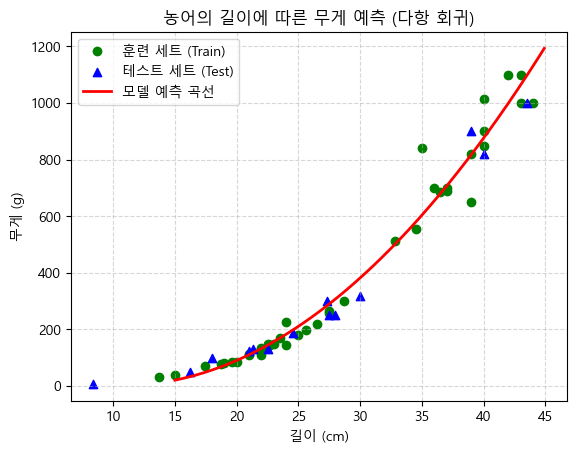

In [9]:
# 무언가
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='malgun gothic')

# 1. 곡선을 부드럽게 그리기 위해 15cm부터 45cm까지 0.1 간격으로 촘촘한 가상의 데이터를 만듭니다.
point = np.arange(15, 45, 0.1).reshape(-1, 1)

# 2. 이 가상의 데이터도 모델이 이해할 수 있게 똑같이 2차항(제곱) 형태로 변환합니다.
point_poly = poly.transform(point)

# 3. 모델(lr)을 사용해 가상 데이터들의 예상 무게(y값)를 예측합니다.
point_pred = lr.predict(point_poly)

# 4. 훈련 세트와 테스트 세트를 산점도(점)로 그립니다.
plt.scatter(x_train, y_train, c='g', label='훈련 세트 (Train)')
plt.scatter(x_test, y_test, c='b', marker='^', label='테스트 세트 (Test)')

# 5. 모델이 학습한 예측 곡선을 선(Line)으로 그립니다.
plt.plot(point, point_pred, color='red', linewidth=2, label='모델 예측 곡선')

# 6. 그래프를 보기 좋게 꾸밉니다.
plt.title('농어의 길이에 따른 무게 예측 (다항 회귀)')
plt.xlabel('길이 (cm)')
plt.ylabel('무게 (g)')
plt.legend() # 범례 표시
plt.grid(True, linestyle='--', alpha=0.5)

# 7. 그래프 출력
plt.show()
